In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Locate dataset
import os
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "TRAIN" in dirs:
        print("FOUND TRAIN at:")
        print(os.path.join(root, "TRAIN"))

# Dataset paths
BASE_DIR = "/content/drive/MyDrive/ Project/archive (2)/dataset"
TRAIN_DIR = BASE_DIR + "/TRAIN"
VAL_DIR   = BASE_DIR + "/VAL"
TEST_DIR  = BASE_DIR + "/TEST"

# Image preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# EfficientNetV2L model (feature extraction)
from tensorflow.keras.applications import EfficientNetV2L
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetV2L(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  # Feature extraction

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Mounted at /content/drive
FOUND TRAIN at:
/content/drive/MyDrive/ Project/archive (2)/dataset/TRAIN
Found 9126 images belonging to 2 classes.
Found 1109 images belonging to 2 classes.
Found 1141 images belonging to 2 classes.
473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      9,216 │ stem_activation[… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │        128 │ block1a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_add (Add)   │ (None, 112, 112,  │          0 │ block1a_project_… │
│                     │ 32)               │            │ stem_activation[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 112, 112,  │      9,216 │ block1a_add[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 112, 112,  │        128 │ block1b_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 112, 112,  │          0 │ block1b_drop[0][… │
│                     │ 32)               │            │ block1a_add[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_co… │ (None, 112, 112,  │      9,216 │ block1b_add[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_bn  │ (None, 112, 112,  │        128 │ block1c_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1c_project_ac… │ (None, 112, 112,  │          0 │ block1c_project_

 Total params: 118,080,161 (450.44 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 117,749,408 (449.18 MB)

In [3]:
# Import EarlyStopping callback
# This is used to stop training automatically when the model stops improving
from tensorflow.keras.callbacks import EarlyStopping

# Create an EarlyStopping object
early_stop = EarlyStopping(        # Monitor validation accuracy during training
    monitor="val_accuracy",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=6,
    steps_per_epoch=60,
    validation_steps=30,
    callbacks=[early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 2182s 35s/step - accuracy: 0.6212 - loss: 0.7615 - val_accuracy: 0.7344 - val_loss: 0.5879
Epoch 2/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 2030s 34s/step - accuracy: 0.7461 - loss: 0.5992 - val_accuracy: 0.7802 - val_loss: 0.5315
Epoch 3/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 2067s 35s/step - accuracy: 0.7436 - loss: 0.5630 - val_accuracy: 0.7698 - val_loss: 0.4951
Epoch 4/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 2050s 34s/step - accuracy: 0.7601 - loss: 0.5572 - val_accuracy: 0.8000 - val_loss: 0.4623
Epoch 5/6
46/60 ━━━━━━━━━━━━━━━━━━━━ 5:20 23s/step - accuracy: 0.7805 - loss: 0.4964

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


60/60 ━━━━━━━━━━━━━━━━━━━━ 1720s 29s/step - accuracy: 0.7788 - loss: 0.4987 - val_accuracy: 0.7937 - val_loss: 0.4553
Epoch 6/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 2150s 35s/step - accuracy: 0.7670 - loss: 0.5178 - val_accuracy: 0.7958 - val_loss: 0.4531


In [4]:
# Test evaluation
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)

# Detailed metrics
from sklearn.metrics import classification_report, roc_auc_score

y_pred_prob = model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()
y_true = test_generator.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Pneumonia"]
))

roc_auc = roc_auc_score(y_true, y_pred_prob)
print("ROC-AUC:", roc_auc)


36/36 ━━━━━━━━━━━━━━━━━━━━ 794s 22s/step - accuracy: 0.8494 - loss: 0.4111
Test Accuracy: 0.7861524820327759
36/36 ━━━━━━━━━━━━━━━━━━━━ 805s 22s/step
              precision    recall  f1-score   support

      Normal       0.73      0.92      0.81       571
   Pneumonia       0.89      0.66      0.75       570

    accuracy                           0.79      1141
   macro avg       0.81      0.79      0.78      1141
weighted avg       0.81      0.79      0.78      1141

ROC-AUC: 0.8754047992134452


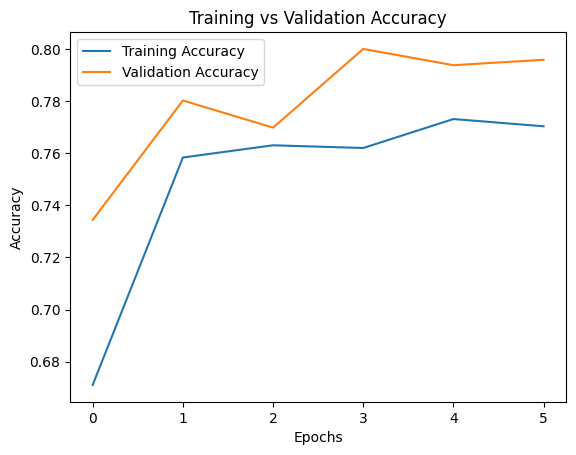

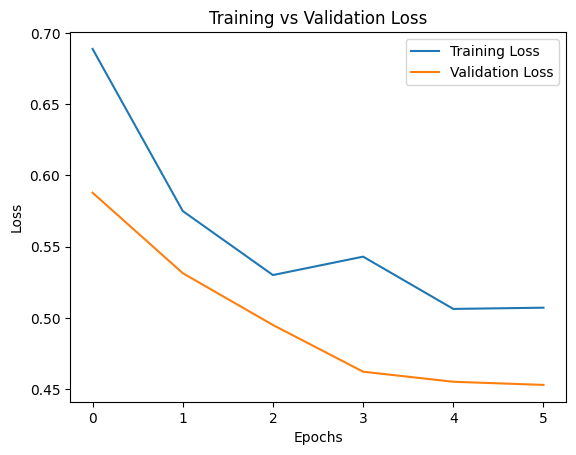

In [5]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


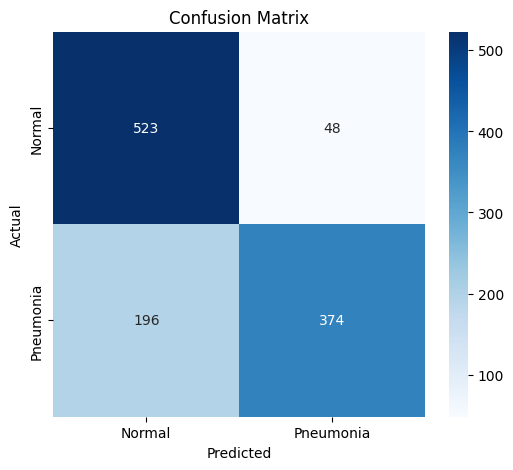

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


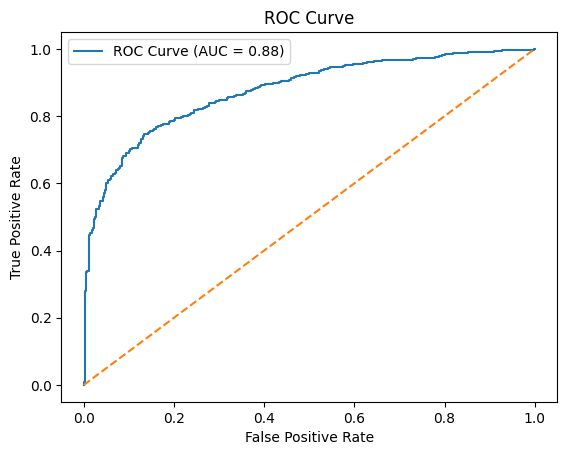

In [7]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='ROC Curve (AUC = %.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


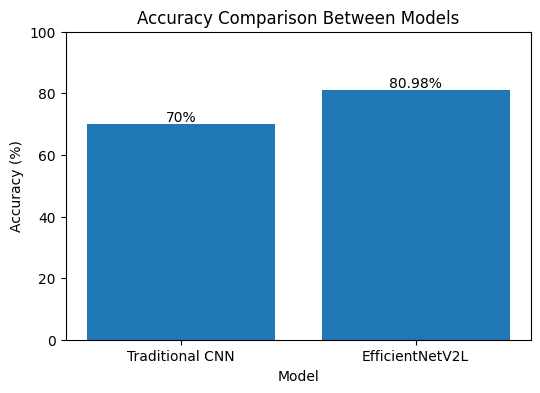

In [8]:
import matplotlib.pyplot as plt

models = ['Traditional CNN', 'EfficientNetV2L']
accuracy = [70, 80.98]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.title('Accuracy Comparison Between Models')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for i, v in enumerate(accuracy):
    plt.text(i, v + 1, f"{v}%", ha='center')

plt.show()


In [ ]:
model.save("efficientnetv2l_feature_extraction_final.keras")
